# MRR Bridge Analysis
**Dataset:** RavenStack — 5,000 subscription records  
**Goal:** Decompose monthly MRR movement into New / Expansion / Churned / Net New components

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Libraries loaded.')

Libraries loaded.


In [2]:
subs = pd.read_csv('../data/subscriptions.csv', parse_dates=['start_date', 'end_date'])
print(f'Subscriptions: {len(subs):,} rows')
print(f'Date range: {subs.start_date.min().date()} → {subs.start_date.max().date()}')
print(f'\nChurn flag distribution:')
print(subs['churn_flag'].value_counts())
print(f'\nUpgrade flag distribution:')
print(subs['upgrade_flag'].value_counts())
print(f'\nMRR stats (non-trial):')
print(subs[subs['is_trial']==False]['mrr_amount'].describe().round(2))

Subscriptions: 5,000 rows
Date range: 2023-01-09 → 2024-12-31

Churn flag distribution:
churn_flag
False    4514
True      486
Name: count, dtype: int64

Upgrade flag distribution:
upgrade_flag
False    4471
True      529
Name: count, dtype: int64

MRR stats (non-trial):
count     4222.00
mean      2685.63
std       3569.43
min         19.00
25%        539.00
50%       1244.50
75%       3381.00
max      33830.00
Name: mrr_amount, dtype: float64


## Step 1: Assign each subscription to a calendar month bucket

In [3]:
subs['start_month'] = subs['start_date'].dt.to_period('M')
subs['end_month']   = subs['end_date'].dt.to_period('M')

# Build a complete monthly calendar spanning the dataset
all_months = pd.period_range(
    start=subs['start_date'].min().to_period('M'),
    end=subs['start_date'].max().to_period('M'),
    freq='M'
)
print(f'Monthly periods: {all_months[0]} → {all_months[-1]} ({len(all_months)} months)')

Monthly periods: 2023-01 → 2024-12 (24 months)


## Step 2: Build MRR Bridge — New, Expansion, Churned, Net New per month

In [4]:
records = []

for month in all_months:
    # NEW MRR: paid subscriptions that started this month, not an upgrade (organic new)
    new_mask = (
        (subs['start_month'] == month) &
        (subs['is_trial'] == False) &
        (subs['upgrade_flag'] == False)
    )
    new_mrr = subs.loc[new_mask, 'mrr_amount'].sum()

    # EXPANSION MRR: upgrades that started this month (upgrade_flag = True)
    expansion_mask = (
        (subs['start_month'] == month) &
        (subs['upgrade_flag'] == True) &
        (subs['is_trial'] == False)
    )
    expansion_mrr = subs.loc[expansion_mask, 'mrr_amount'].sum()

    # CHURNED MRR: subscriptions that ended (churned) in this month
    churn_mask = (
        (subs['end_month'] == month) &
        (subs['churn_flag'] == True)
    )
    churned_mrr = subs.loc[churn_mask, 'mrr_amount'].sum()

    net_new_mrr = new_mrr + expansion_mrr - churned_mrr

    records.append({
        'month': month,
        'new_mrr': new_mrr,
        'expansion_mrr': expansion_mrr,
        'churned_mrr': churned_mrr,
        'net_new_mrr': net_new_mrr
    })

bridge = pd.DataFrame(records)
bridge['month_str'] = bridge['month'].dt.strftime('%b %Y')

# Cumulative ARR
bridge['cumulative_mrr'] = bridge['net_new_mrr'].cumsum()
bridge['implied_arr'] = bridge['cumulative_mrr'] * 12

print('MRR Bridge (monthly, first 6 rows):')
print(bridge[['month_str', 'new_mrr', 'expansion_mrr', 'churned_mrr', 'net_new_mrr']].head(6).to_string(index=False))
print(f'\nTotal New MRR generated: ${bridge["new_mrr"].sum():,.0f}')
print(f'Total Expansion MRR: ${bridge["expansion_mrr"].sum():,.0f}')
print(f'Total Churned MRR: ${bridge["churned_mrr"].sum():,.0f}')
print(f'Net MRR change overall: ${bridge["net_new_mrr"].sum():,.0f}')

MRR Bridge (monthly, first 6 rows):
month_str  new_mrr  expansion_mrr  churned_mrr  net_new_mrr
 Jan 2023     1102           3582            0         4684
 Feb 2023    11003             76            0        11079
 Mar 2023    19881           6004            0        25885
 Apr 2023    35055           6733          245        41543
 May 2023    73780          12139            0        85919
 Jun 2023    56585          18402         1176        73811

Total New MRR generated: $10,075,750
Total Expansion MRR: $1,262,997
Total Churned MRR: $1,179,139
Net MRR change overall: $10,159,608


## Step 3: Stacked Bar MRR Bridge Chart

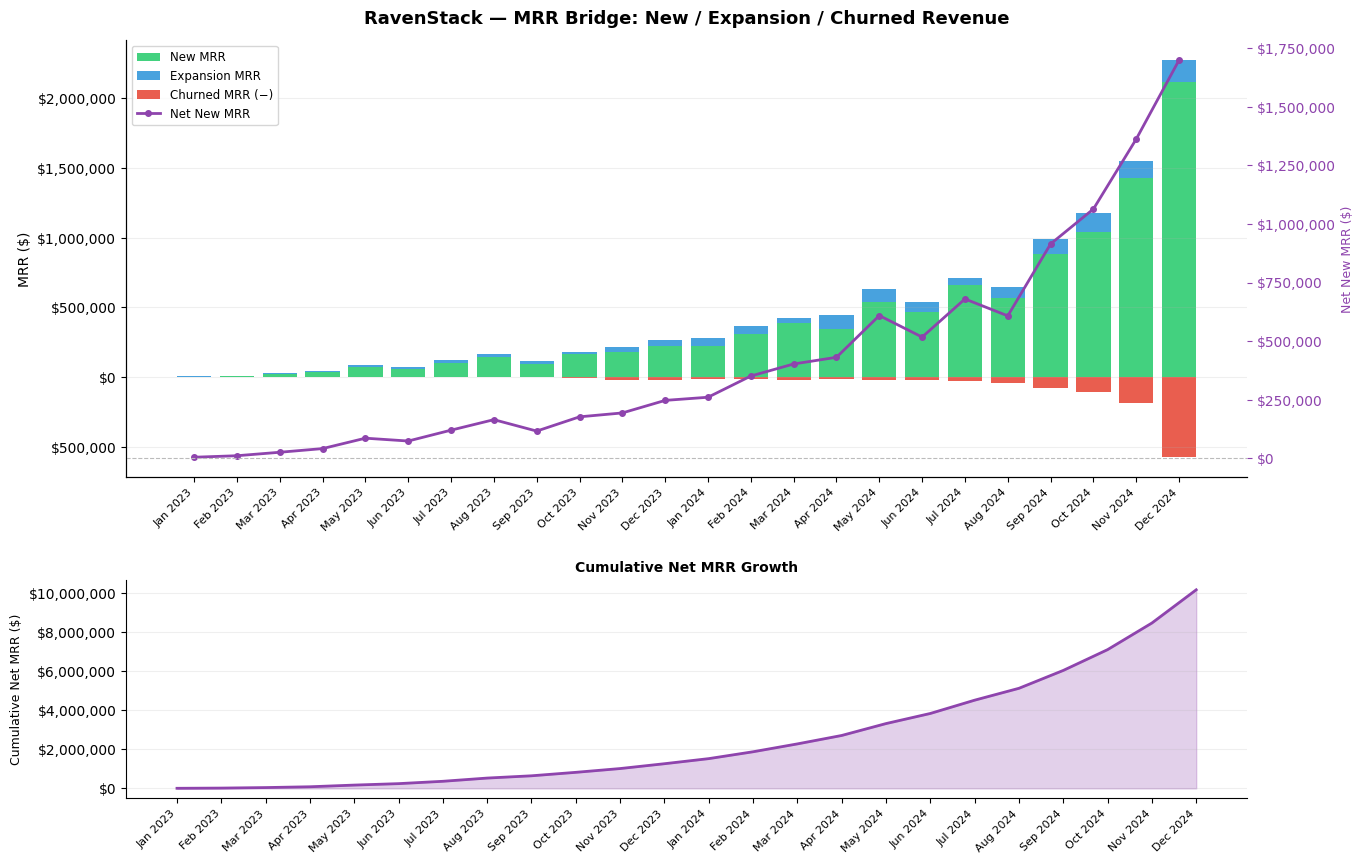

Saved: mrr_bridge.png


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})

months_idx = range(len(bridge))
x_labels = bridge['month_str'].tolist()

# Color palette
C_NEW  = '#2ecc71'
C_EXP  = '#3498db'
C_CHURN = '#e74c3c'
C_NET  = '#8e44ad'

# --- Top chart: Stacked bar (New + Expansion positive, Churned negative) ---
ax1.bar(months_idx, bridge['new_mrr'],       color=C_NEW,   label='New MRR',       alpha=0.9)
ax1.bar(months_idx, bridge['expansion_mrr'], color=C_EXP,   label='Expansion MRR', alpha=0.9,
        bottom=bridge['new_mrr'])
ax1.bar(months_idx, -bridge['churned_mrr'],  color=C_CHURN, label='Churned MRR (−)', alpha=0.9)

# Net new MRR line
ax1_twin = ax1.twinx()
ax1_twin.plot(months_idx, bridge['net_new_mrr'], color=C_NET,
              linewidth=2, marker='o', markersize=4, label='Net New MRR')
ax1_twin.axhline(0, color='#bbb', linewidth=0.8, linestyle='--')
ax1_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1_twin.set_ylabel('Net New MRR ($)', color=C_NET, fontsize=9)
ax1_twin.tick_params(axis='y', colors=C_NET)
ax1_twin.spines['top'].set_visible(False)

ax1.set_xticks(months_idx)
ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${abs(x):,.0f}'))
ax1.set_ylabel('MRR ($)', fontsize=10)
ax1.set_title('RavenStack — MRR Bridge: New / Expansion / Churned Revenue', fontsize=13, fontweight='bold', pad=12)
ax1.grid(axis='y', alpha=0.2)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=8.5)

# --- Bottom chart: Cumulative Net MRR ---
ax2.fill_between(months_idx, bridge['cumulative_mrr'], alpha=0.25, color=C_NET)
ax2.plot(months_idx, bridge['cumulative_mrr'], color=C_NET, linewidth=2)
ax2.set_xticks(months_idx)
ax2.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_ylabel('Cumulative Net MRR ($)', fontsize=9)
ax2.set_title('Cumulative Net MRR Growth', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.2)

plt.tight_layout(pad=2)
plt.savefig('../outputs/mrr_bridge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mrr_bridge.png')

## Step 4: MRR Bridge by Plan Tier

In [6]:
# Annual MRR summary by tier
tier_summary = []
for tier in ['Basic', 'Pro', 'Enterprise']:
    t = subs[(subs['plan_tier'] == tier) & (subs['is_trial'] == False)]
    new_mrr = t[t['upgrade_flag'] == False]['mrr_amount'].sum()
    exp_mrr = t[t['upgrade_flag'] == True]['mrr_amount'].sum()
    churn_mrr = t[t['churn_flag'] == True]['mrr_amount'].sum()
    active_mrr = t[t['churn_flag'] == False]['mrr_amount'].sum()
    tier_summary.append({
        'Tier': tier,
        'Total New MRR': f'${new_mrr:,.0f}',
        'Expansion MRR': f'${exp_mrr:,.0f}',
        'Churned MRR':   f'${churn_mrr:,.0f}',
        'Active MRR':    f'${active_mrr:,.0f}'
    })

tier_df = pd.DataFrame(tier_summary)
print('MRR Summary by Plan Tier:')
print(tier_df.to_string(index=False))

MRR Summary by Plan Tier:
      Tier Total New MRR Expansion MRR Churned MRR Active MRR
     Basic      $700,321       $60,116     $72,523   $687,914
       Pro    $1,823,976      $281,113    $180,271 $1,924,818
Enterprise    $7,551,453      $921,768    $926,345 $7,546,876


## Step 5: Key Findings

In [7]:
best_month_idx = bridge['new_mrr'].idxmax()
worst_churn_idx = bridge['churned_mrr'].idxmax()

print('=' * 55)
print('KEY FINDINGS — MRR BRIDGE')
print('=' * 55)
print(f'Total New MRR generated:     ${bridge["new_mrr"].sum():>10,.0f}')
print(f'Total Expansion MRR:         ${bridge["expansion_mrr"].sum():>10,.0f}')
print(f'Total Churned MRR:           ${bridge["churned_mrr"].sum():>10,.0f}')
print(f'Net MRR over period:         ${bridge["net_new_mrr"].sum():>10,.0f}')
print(f'Peak new MRR month:          {bridge.loc[best_month_idx, "month_str"]} (${bridge.loc[best_month_idx, "new_mrr"]:,.0f})')
print(f'Peak churn month:            {bridge.loc[worst_churn_idx, "month_str"]} (${bridge.loc[worst_churn_idx, "churned_mrr"]:,.0f})')
net_positive = (bridge['net_new_mrr'] > 0).sum()
print(f'Months with net MRR growth:  {net_positive}/{len(bridge)}')
print('=' * 55)

KEY FINDINGS — MRR BRIDGE
Total New MRR generated:     $10,075,750
Total Expansion MRR:         $ 1,262,997
Total Churned MRR:           $ 1,179,139
Net MRR over period:         $10,159,608
Peak new MRR month:          Dec 2024 ($2,113,247)
Peak churn month:            Dec 2024 ($574,643)
Months with net MRR growth:  24/24
